# 第一课：Token 的奇妙旅程：从哪里来，到哪里去？

在这节课中，我们将深入大语言模型（LLM）的底层，探索 LLM 能够理解和生成的最小单位 —— **Token**。
我们会解答以下问题：
- **Token 是什么？** 大语言模型的工作模式是什么？
- **为什么我们需要分词方案（Tokenizer）？** BPE 算法是什么？
- **Token 如何变成可计算的？** 探索 Embedding 层。
- **整个流转过程是怎样的？** 从 Token 输入到下一个 Token 输出的 Transformer 之旅。

⏸ 关于多模态 Token（视觉、音频等），我们将在 [多模态 Token 探秘](./multimodal_tokens.ipynb) 中深入探讨。

## 1. 大语言模型的工作模式与 Token 的概念

大语言模型（如 ChatGPT, Qwen, Llama）的核心工作模式其实非常简单：**“给定一段上下文，预测下一个‘字’应该是什么”**。这种模式被称为**自回归（Autoregressive）生成**。

然而，这里说的“字”并不是我们日常理解中的汉字或英文字母，而是 **Token**。
Token 是模型处理信息的最小基本单位。它可能是一个词、一个字、甚至是一个词根。

让我们通过实际的代码来看看，一句话是如何被切分成 Token 的。

In [1]:
from modelscope import AutoTokenizer, AutoModelForCausalLM

tokenizer_id = "Qwen/Qwen3.5-0.8B"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_id)

text = "Tokenization is awesome! 深度学习非常有趣。"
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.encode(text)

print(f"原始文本: {text}")
print(f"\n--- 分词结果 ---")
for i, (tok, tid) in enumerate(zip(tokens, token_ids)):
    decoded = tokenizer.decode([tid])
    print(f"  [{i}] Token: {tok!r:20s}  ->  解码: {decoded!r:10s}  ->  ID: {tid}")
print(f"\nToken IDs: {token_ids}")

2026-05-17 03:28:16,897 - modelscope - INFO - Target directory already exists, skipping creation.


原始文本: Tokenization is awesome! 深度学习非常有趣。

--- 分词结果 ---
  [0] Token: 'Token'               ->  解码: 'Token'     ->  ID: 3214
  [1] Token: 'ization'             ->  解码: 'ization'   ->  ID: 1954
  [2] Token: 'Ġis'                 ->  解码: ' is'       ->  ID: 369
  [3] Token: 'Ġawesome'            ->  解码: ' awesome'  ->  ID: 12099
  [4] Token: '!'                   ->  解码: '!'         ->  ID: 0
  [5] Token: 'Ġ'                   ->  解码: ' '         ->  ID: 220
  [6] Token: 'æ·±åº¦åŃ¦ä¹ł'        ->  解码: '深度学习'      ->  ID: 124089
  [7] Token: 'éĿŀå¸¸'              ->  解码: '非常'        ->  ID: 96762
  [8] Token: 'æľīè¶£'              ->  解码: '有趣'        ->  ID: 101858
  [9] Token: 'ãĢĤ'                 ->  解码: '。'         ->  ID: 1710

Token IDs: [3214, 1954, 369, 12099, 0, 220, 124089, 96762, 101858, 1710]


### “乱码”的秘密：Byte-to-Unicode 映射详解

上面的分词结果中，中文 Token 看起来像乱码（如 `æ·±åº¦` 其实是 `深度`）。这并不是 bug，而是 **BBPE (Byte-level BPE)** 的设计决定的。让我们彻底搞清楚这个过程：

**第一步：中文先被编码为 UTF-8 字节**

每个中文字在 UTF-8 中占 3 个字节。例如 `深` 的 UTF-8 编码是 `0xE6 0xB7 0xB1`。

**第二步：BBPE 在字节级别进行合并**

BPE 算法直接在这些原始字节上运作，将高频出现的字节序列合并成新的 Token。但是，字节值 0-255 中有很多是不可见字符（如控制字符 0x00-0x1F），无法直接用字符串表示。

**第三步：字节值通过 Byte-to-Unicode 表映射为可见字符**

GPT-2 引入了一张映射表，将每个字节值 (0-255) 映射为一个可见的 Unicode 字符：
- 可见的 ASCII 字节（33-126）、拉丁字符（161-172, 174-255）直接保持不变
- 不可见的字节（0-32, 127-160, 173）被映射到 U+0100 以后的 Unicode 区域

这就是为什么 `0xE6` 显示为 `æ`，`0xB7` 显示为 `·`，`0xB1` 显示为 `±` —— 它们刚好都在“直接保持不变”的范围内！

**解码过程则是完全相反的：** Token 字符串 -> 查 Byte-to-Unicode 反向映射表还原为原始字节 -> 将字节序列用 UTF-8 解码 -> 得到可读文本。

让我们用代码完整地演示这个过程：

In [2]:
def bytes_to_unicode():
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1
    return dict(zip(bs, [chr(c) for c in cs]))

b2u = bytes_to_unicode()
u2b = {v: k for k, v in b2u.items()}

zh_text = "深度学习"
print(f"原始中文: {zh_text}")
print(f"字符数: {len(zh_text)}")

print(f"\n=== 第一步: UTF-8 编码 ===")
utf8_bytes = zh_text.encode('utf-8')
print(f"UTF-8 字节: {list(utf8_bytes)}")
print(f"字节数: {len(utf8_bytes)} (每个汉字 3 个字节)")

print(f"\n=== 第二步: 逐字节展示 ===")
for i, char in enumerate(zh_text):
    char_bytes = char.encode('utf-8')
    byte_str = ' '.join(f'0x{b:02X}' for b in char_bytes)
    unicode_str = ''.join(b2u[b] for b in char_bytes)
    print(f"  '{char}' -> 字节 [{byte_str}] -> Byte-to-Unicode 映射: '{unicode_str}'")

print(f"\n=== 第三步: 整体映射结果 ===")
full_mapped = ''.join(b2u[b] for b in utf8_bytes)
print(f"字节序列: {list(utf8_bytes)}")
print(f"Byte-to-Unicode 映射后: '{full_mapped}'")
print(f"这就是 tokenizer.tokenize() 返回的“乱码”!")

print(f"\n=== 第四步: 反向解码（“乱码” -> 中文）===")
recovered_bytes = bytes([u2b[c] for c in full_mapped])
recovered_text = recovered_bytes.decode('utf-8')
print(f"“乱码”字符串: '{full_mapped}'")
print(f"反向映射回字节: {list(recovered_bytes)}")
print(f"UTF-8 解码: '{recovered_text}'")
print(f"解码结果与原文一致: {recovered_text == zh_text}")

print(f"\n=== 完整轮转示意 ===")
print(f"中文 '深度学习' -> UTF-8 字节 [0xE6,0xB7,0xB1,0xE5,0xBA,0xA6,0xE5,0xAD,0xA6] -> Byte-to-Unicode 'æ·±åº¦åŃ¦' -> 反向映射+解码 -> '深度学习'")

原始中文: 深度学习
字符数: 4

=== 第一步: UTF-8 编码 ===
UTF-8 字节: [230, 183, 177, 229, 186, 166, 229, 173, 166, 228, 185, 160]
字节数: 12 (每个汉字 3 个字节)

=== 第二步: 逐字节展示 ===
  '深' -> 字节 [0xE6 0xB7 0xB1] -> Byte-to-Unicode 映射: 'æ·±'
  '度' -> 字节 [0xE5 0xBA 0xA6] -> Byte-to-Unicode 映射: 'åº¦'
  '学' -> 字节 [0xE5 0xAD 0xA6] -> Byte-to-Unicode 映射: 'åŃ¦'
  '习' -> 字节 [0xE4 0xB9 0xA0] -> Byte-to-Unicode 映射: 'ä¹ł'

=== 第三步: 整体映射结果 ===
字节序列: [230, 183, 177, 229, 186, 166, 229, 173, 166, 228, 185, 160]
Byte-to-Unicode 映射后: 'æ·±åº¦åŃ¦ä¹ł'
这就是 tokenizer.tokenize() 返回的“乱码”!

=== 第四步: 反向解码（“乱码” -> 中文）===
“乱码”字符串: 'æ·±åº¦åŃ¦ä¹ł'
反向映射回字节: [230, 183, 177, 229, 186, 166, 229, 173, 166, 228, 185, 160]
UTF-8 解码: '深度学习'
解码结果与原文一致: True

=== 完整轮转示意 ===
中文 '深度学习' -> UTF-8 字节 [0xE6,0xB7,0xB1,0xE5,0xBA,0xA6,0xE5,0xAD,0xA6] -> Byte-to-Unicode 'æ·±åº¦åŃ¦' -> 反向映射+解码 -> '深度学习'


### 为什么 Token 和我们理解的“字”不一样？

观察上面的分词结果你会发现：
1. 英文中的 `Tokenization` 被切分成了 `Token` 和 `ization` 两个子词（Subword），这是因为 BPE 算法根据语料频率决定切分粒度。
2. 中文的“深度学习非常有趣”被切分成了若干个 Token，每个 Token 可能对应一个或多个汉字。
3. 现在你已经知道，`tokenize()` 返回的中文 Token 看起来像乱码，是因为它展示的是 **Byte 级别经过 Byte-to-Unicode 映射后的内部表示**。但模型内部并不直接使用这些字符串，而是使用 **Token ID**（整数索引）。通过 `decode()` 方法，我们可以从 Token ID 完美还原出原始文本。

**为什么不直接用字母或汉字？**
- **如果用字母（Character-level）**：英文只有 26 个字母，词表极小。但一句话会变成非常长的序列，模型需要看很远才能理解一个词的意思，计算效率极低，且难以捕捉语义。
- **如果用词（Word-level）**：“学习”、“学过”、“学了”会被当成完全不同的独立词汇，导致词表无限膨胀（Out-Of-Vocabulary 问题），且无法学习到词根之间的关联。

这就引入了现代大模型最常用的分词方案 —— **BPE (Byte-Pair Encoding)**。

## 2. 分词方案：BPE (Byte-Pair Encoding) 算法解析

BPE 是一种**数据驱动**的子词（Subword）分词算法。它的核心思想是：**找到语料库中最常连续出现的字符组合，把它们合并成一个新的 Token。**

- **对于英文**：像 "ing", "ly", "tion" 这样的常见词缀会被合并成一个独立的 Token，而生僻词会被拆解成常见的词根。
- **对于中文**：因为 UTF-8 编码下一个汉字占 3 个 Byte。很多基于 BPE 的模型是在 Byte 级别进行合并的（BBPE）。常见的汉字组合（如“中国”、“深度”）会成为独立的 Token，而生僻字可能会被拆解为底层的 Byte 组合。

这也是为什么 `tokenize()` 方法对中文返回的 Token 看起来像乱码 —— 它展示的是 Byte 级别的内部表示。但模型内部并不直接使用这些字符串，而是使用 **Token ID**（整数索引）。通过 `decode()` 方法，我们可以从 Token ID 完美还原出原始文本。

### 探索词表：模型“认识”多少个 Token？

每个 Tokenizer 都有一个固定的**词表（Vocabulary）**，里面存储了所有它“认识”的 Token。让我们来看看 Qwen3.5 的词表长什么样。

In [3]:
print(f"模型: {tokenizer_id}")
print(f"词表大小 (vocab_size): {len(tokenizer)}")
print(f"模型最大输入长度: {tokenizer.model_max_length}")
print(f"\n--- 特殊 Token ---")
special_tokens = tokenizer.special_tokens_map
for name, value in special_tokens.items():
    token_id = tokenizer.convert_tokens_to_ids(value)
    print(f"  {name:15s} -> {value!r:20s}  (ID: {token_id})")

print(f"\n--- 词表中的 Token 示例 ---")
examples = ["hello", "世界", "ing", "Ġthe", "Ġis", "</w>"]
for ex in examples:
    tid = tokenizer.convert_tokens_to_ids(ex)
    in_vocab = tid != tokenizer.unk_token_id
    status = f"ID={tid}" if in_vocab else f"不在词表中 (返回 UNK ID={tid})"
    print(f"  {ex!r:20s} -> {status}")

print(f"\n--- 词表 ID 范围 ---")
print(f"  最小 ID: 0, 最大 ID: {len(tokenizer) - 1}")
print(f"\n--- 词表首尾 Token ---")
for i in [0, 1, 2, 3, 4]:
    print(f"  ID {i}: {tokenizer.decode([i])!r}")
print(f"  ...")
for i in range(len(tokenizer) - 3, len(tokenizer)):
    print(f"  ID {i}: {tokenizer.decode([i])!r}")

模型: Qwen/Qwen3.5-0.8B
词表大小 (vocab_size): 248077
模型最大输入长度: 262144

--- 特殊 Token ---
  eos_token       -> '<|im_end|>'          (ID: 248046)
  pad_token       -> '<|endoftext|>'       (ID: 248044)
  audio_bos_token -> '<|audio_start|>'     (ID: 248070)
  audio_eos_token -> '<|audio_end|>'       (ID: 248071)
  audio_token     -> '<|audio_pad|>'       (ID: 248076)
  image_token     -> '<|image_pad|>'       (ID: 248056)
  video_token     -> '<|video_pad|>'       (ID: 248057)
  vision_bos_token -> '<|vision_start|>'    (ID: 248053)
  vision_eos_token -> '<|vision_end|>'      (ID: 248054)

--- 词表中的 Token 示例 ---
  'hello'              -> ID=14556
  '世界'                 -> 不在词表中 (返回 UNK ID=None)
  'ing'                -> ID=286
  'Ġthe'               -> ID=279
  'Ġis'                -> ID=369
  '</w>'               -> 不在词表中 (返回 UNK ID=None)

--- 词表 ID 范围 ---
  最小 ID: 0, 最大 ID: 248076

--- 词表首尾 Token ---
  ID 0: '!'
  ID 1: '"'
  ID 2: '#'
  ID 3: '$'
  ID 4: '%'
  ...
  ID 248074: '<tts_text_eo

### 中美模型分词对比：Qwen3.5 vs Gemma-4

不同的模型用了不同的词表和分词策略。中国的 Qwen 和美国的 Gemma，对同一段中英文的分词结果会有什么不同？这个对比能让我们直观地看到：**词表的设计如何影响模型对不同语言的处理效率**。

In [8]:
from modelscope import AutoTokenizer as MS_AutoTokenizer
import logging
logging.getLogger("modelscope").setLevel(logging.ERROR)

gemma_tokenizer = MS_AutoTokenizer.from_pretrained("google/gemma-4-E2B-it")

zh_text = "为什么总是天上有星星？为什么你的眼里总是亮晶晶？"
en_text = "Why is there always starlight in the sky? Why are your eyes always sparkling?"

models = [
    ("Qwen3.5 (中国)", tokenizer),
    ("Gemma-4 (美国)", gemma_tokenizer),
]

for lang_label, txt in [("中文", zh_text), ("英文", en_text)]:
    print(f"\n{'='*60}")
    print(f"{lang_label}: {txt}")
    print(f"{'='*60}")
    for model_label, tok in models:
        ids = tok.encode(txt)
        decoded_tokens = [tok.decode([tid]) for tid in ids]
        print(f"\n  [{model_label}]")
        print(f"  词表大小: {len(tok):,}  |  Token 数量: {len(ids)}")
        print(f"  逐 Token 解码: {decoded_tokens}")

print(f"\n\n=== 小结 ===")
print(f"中文场景: Qwen 的词表包含大量中文词组，同样的中文只需要更少的 Token。")
print(f"英文场景: 两个模型差异不大，但分词边界不同（如 'starlight' vs 'st'+'arlight'）。")
print(f"这就是为什么使用非中文优化的大模型 API 时，中文prompt的 Token 消耗和费用通常比英文更高")


中文: 为什么总是天上有星星？为什么你的眼里总是亮晶晶？

  [Qwen3.5 (中国)]
  词表大小: 248,077  |  Token 数量: 13
  逐 Token 解码: ['为什么', '总是', '天', '上有', '星星', '？', '为什么', '你的', '眼里', '总是', '亮', '晶晶', '？']

  [Gemma-4 (美国)]
  词表大小: 262,144  |  Token 数量: 14
  逐 Token 解码: ['为什么', '总是', '天', '上有', '星星', '？', '为什么', '你的', '眼里', '总是', '亮', '晶', '晶', '？']

英文: Why is there always starlight in the sky? Why are your eyes always sparkling?

  [Qwen3.5 (中国)]
  词表大小: 248,077  |  Token 数量: 17
  逐 Token 解码: ['Why', ' is', ' there', ' always', ' star', 'light', ' in', ' the', ' sky', '?', ' Why', ' are', ' your', ' eyes', ' always', ' sparkling', '?']

  [Gemma-4 (美国)]
  词表大小: 262,144  |  Token 数量: 17
  逐 Token 解码: ['Why', ' is', ' there', ' always', ' st', 'arlight', ' in', ' the', ' sky', '?', ' Why', ' are', ' your', ' eyes', ' always', ' sparkling', '?']


=== 小结 ===
中文场景: Qwen 的词表包含大量中文词组，同样的中文只需要更少的 Token。
英文场景: 两个模型差异不大，但分词边界不同（如 'starlight' vs 'st'+'arlight'）。
这就是为什么使用非中文优化的大模型 API 时，中文prompt的 Token 消耗和费用通常比英文更高


## 3. Token 怎么变成可计算的？(Embedding 可视化)

神经网络无法直接计算字符串（如 "Token" 或 "学习"）或整数 ID（如 1234）。我们需要将离散的 Token 映射为连续的稠密向量，这就是 **Embedding（词嵌入）**。

这些 Embedding 并不是随机瞎猜的，而是**跟随 LLM 的整个训练过程一起学习得到的**。意思相近或语法作用相似的 Token，它们在高维空间中的向量距离也会更近。

我们来加载 Qwen3.5-0.8B 模型，提取它的 Embedding 层（即第一层），并直观地看一看。

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Embedding 层结构: Embedding(248320, 1024)

提取的向量矩阵形状: torch.Size([7, 1024]) -> 代表 7 个词，每个词 1024 维


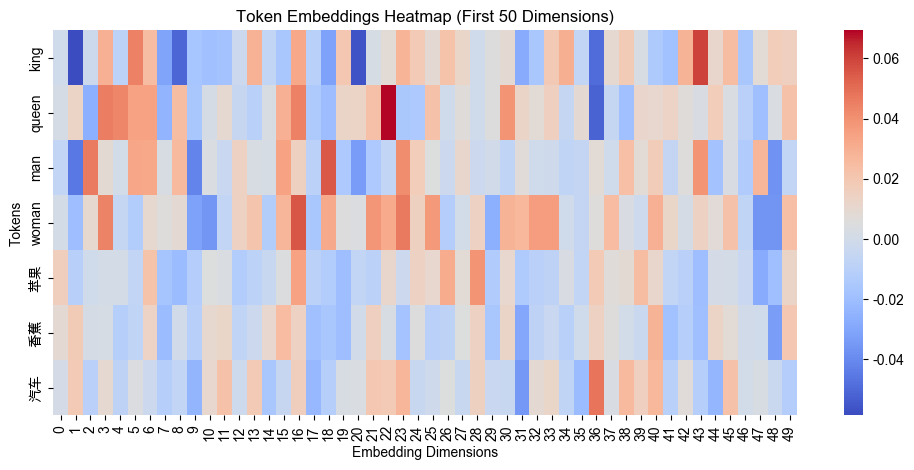

In [5]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("modelscope").setLevel(logging.ERROR)

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

model = AutoModelForCausalLM.from_pretrained(tokenizer_id)

embedding_layer = model.get_input_embeddings()
print(f"Embedding 层结构: {embedding_layer}")

words = ["king", "queen", "man", "woman", "苹果", "香蕉", "汽车"]
word_ids = [tokenizer.encode(w)[0] for w in words]

with torch.no_grad():
    word_embeddings = embedding_layer(torch.tensor(word_ids))

print(f"\n提取的向量矩阵形状: {word_embeddings.shape} -> 代表 {len(words)} 个词，每个词 {word_embeddings.shape[1]} 维")

plt.figure(figsize=(12, 5))
sns.heatmap(word_embeddings[:, :50].float().numpy(), cmap="coolwarm", yticklabels=words)
plt.title("Token Embeddings Heatmap (First 50 Dimensions)")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Tokens")
plt.show()

## 4. 整个流转过程：从 Token 到预测结果的“下一个 Token”

一个 Token 进入模型后，经历了怎样的奇幻漂流？整个流水线如下：

1. **输入阶段**：输入文本 $\rightarrow$ Tokenize 得到 `[ID_1, ID_2, ...]` $\rightarrow$ 查表得到 **Embedding 矩阵**。
2. **Transformer 层 (多层变换)**：
    - 向量矩阵进入几十层叠加的 Transformer Block。
    - **自注意力机制 (Self-Attention)**：这也是一种“线性+Softmax”操作，向量们开始互相“交流”。每个 Token 根据上下文，吸收其他 Token 的信息，更新自己的表示。
    - **前馈神经网络 (MLP/FFN)**：对更新后的向量进行线性映射 + 非线性激活函数（如 SwiGLU），完成高维空间的特征提取。
3. **输出阶段**：
    - 最后一层的隐藏状态向量（Hidden States）通过一个线性层（通常叫做 `lm_head`），将其**映射回词表大小的维度**。
    - 这些维度的值代表了预测每一个可能词汇的**原始得分 (Logits)**。
    - 经过 **Softmax** 函数，将得分转化为概率（总和为 1）。
    - 选出概率最高（或通过 Top-K 采样）的 Token ID，作为预测的下一个 Token。

让我们用代码把这个黑盒拆解，单步执行一遍前向传播（Forward Pass）！

In [6]:
import torch.nn.functional as F

if 'model' not in dir():
    model = AutoModelForCausalLM.from_pretrained(tokenizer_id)
    print("模型已重新加载")

input_text = "你爱我，我爱你，蜜雪"
print(f"输入文本: '{input_text}'")

inputs = tokenizer(input_text, return_tensors="pt")
input_ids = inputs["input_ids"]
print(f"\n[Step 1] Token IDs: {input_ids.tolist()[0]}")

with torch.no_grad():
    embeddings = model.model.embed_tokens(input_ids)
print(f"[Step 2] Embedding 形状: {embeddings.shape} -> (batch_size, seq_len, hidden_size)")

with torch.no_grad():
    transformer_outputs = model.model(input_ids)
    hidden_states = transformer_outputs.last_hidden_state
print(f"[Step 3] 最后一层 Hidden States 形状: {hidden_states.shape}")

last_token_hidden_state = hidden_states[:, -1, :]
print(f"[Step 4] 用于预测的最后一个 Token 的向量形状: {last_token_hidden_state.shape}")

with torch.no_grad():
    logits = model.lm_head(last_token_hidden_state)
print(f"[Step 5] Logits 形状: {logits.shape} -> (batch_size, vocab_size={len(tokenizer)})")

probs = F.softmax(logits, dim=-1)
next_token_id = torch.argmax(probs, dim=-1).item()
next_token_str = tokenizer.decode([next_token_id])

print(f"\n=== 预测结果 ===")
print(f"最高概率的 Token ID: {next_token_id}")
print(f"对应的文本是: '{next_token_str}'")
print(f"拼接后的完整句子: '{input_text + next_token_str}'")

输入文本: '你爱我，我爱你，蜜雪'

[Step 1] Token IDs: [95933, 121196, 3709, 115734, 3709, 98735, 97055]
[Step 2] Embedding 形状: torch.Size([1, 7, 1024]) -> (batch_size, seq_len, hidden_size)
[Step 3] 最后一层 Hidden States 形状: torch.Size([1, 7, 1024])
[Step 4] 用于预测的最后一个 Token 的向量形状: torch.Size([1, 1024])
[Step 5] Logits 形状: torch.Size([1, 248320]) -> (batch_size, vocab_size=248077)

=== 预测结果 ===
最高概率的 Token ID: 97260
对应的文本是: '冰'
拼接后的完整句子: '你爱我，我爱你，蜜雪冰'


### 自回归生成：一个接一个地“吐”出文本

上面我们只预测了一个 Token。但大模型的真正工作方式是 **自回归**的：每预测出一个 Token，就把它拼接到输入后面，再预测下一个，如此循环，直到生成结束符或达到长度上限。

让我们用手动循环的方式，把“你爱我，我爱你，蜜雪”接下去补完：

In [7]:
if 'model' not in dir():
    model = AutoModelForCausalLM.from_pretrained(tokenizer_id)

# Qwen3.5-0.8B 实测无法推理出魔性的歌词，有兴趣可以解开下边注释来试试
# tokenizer_id = "Qwen/Qwen3.5-9B"
# tokenizer = AutoTokenizer.from_pretrained(tokenizer_id)
# model = AutoModelForCausalLM.from_pretrained(tokenizer_id)

generated_text = "你爱我，我爱你，蜜雪"
input_ids = tokenizer.encode(generated_text, return_tensors="pt")
max_new_tokens = 20

print(f"输入: '{generated_text}'")
print(f"\n--- 自回归生成过程 ---")

for step in range(max_new_tokens):
    with torch.no_grad():
        outputs = model.model(input_ids)
        last_hidden = outputs.last_hidden_state[:, -1, :]
        logits = model.lm_head(last_hidden)
        probs = F.softmax(logits, dim=-1)
        next_id = torch.argmax(probs, dim=-1).item()
    
    next_str = tokenizer.decode([next_id])
    generated_text += next_str
    input_ids = torch.cat([input_ids, torch.tensor([[next_id]])], dim=1)
    
    print(f"  Step {step+1:>2d}: 预测 Token '{next_str}' (ID={next_id})  ->  当前文本: '{generated_text}'")
    
    if next_id == tokenizer.eos_token_id:
        print(f"  \u2714 生成结束符出现，停止生成。")
        break

print(f"\n=== 最终结果 ===")
print(f"'{generated_text}'")

输入: '你爱我，我爱你，蜜雪'

--- 自回归生成过程 ---
  Step  1: 预测 Token '冰' (ID=97260)  ->  当前文本: '你爱我，我爱你，蜜雪冰'
  Step  2: 预测 Token '城' (ID=96191)  ->  当前文本: '你爱我，我爱你，蜜雪冰城'
  Step  3: 预测 Token '，' (ID=3709)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，'
  Step  4: 预测 Token '你' (ID=95933)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你'
  Step  5: 预测 Token '爱我' (ID=121196)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我'
  Step  6: 预测 Token '，' (ID=3709)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，'
  Step  7: 预测 Token '我爱你' (ID=115734)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你'
  Step  8: 预测 Token '，' (ID=3709)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，'
  Step  9: 预测 Token '蜜' (ID=98735)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜'
  Step 10: 预测 Token '雪' (ID=97055)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪'
  Step 11: 预测 Token '冰' (ID=97260)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪冰'
  Step 12: 预测 Token '城' (ID=96191)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪冰城'
  Step 13: 预测 Token '，' (ID=3709)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪冰城，'
  Step 14: 预测 Token '你' (ID=95933)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪冰城，你'
  Step 1

## 结语

通过这节课，我们梳理了 **文本 Token** 的前世今生：

从人类可读的**文本** $\rightarrow$ 切分并映射为模型可消化的离散 **Token ID** $\rightarrow$ 转化为高维连续空间的 **Embedding** $\rightarrow$ 在 **Transformer** 的汪洋大海中进行无数次线性和非线性变换 $\rightarrow$ 最终收束为词表大小的 **概率分布** $\rightarrow$ 吐出下一个 **Token**。

而且我们还看到，这个过程可以不断循环 —— 每次预测出的 Token 都会被拼接回输入，成为下一次预测的上下文。这就是大模型“一个字一个字”生成文本的真正原理。

但文本只是世界的一部分。图片、视频、声音……这些模态的信息又是如何变成 Token 的呢？它们和文本 Token 在模型内部是如何共存的？

这些问题，我们将在 **[多模态 Token 探秘](./multimodal_tokens.ipynb)** 中一一揭晓。